In [67]:
%reload_ext autoreload
%autoreload 2
import os
import anndata as ad
import numpy as np 
import pandas as pd 
import seaborn as sns
from scipy import stats
import networkx as nx

import sys
import matplotlib.pyplot as plt
import scanpy as sc 
# import decoupler as dc 
# from scipy.stats import pearsonr
import json
import itertools
import warnings
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.preprocessing import minmax_scale
from statsmodels.formula.api import mixedlm
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error


from src.helper import *

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt, quantile_transformation, zscore_transformation
from task_grn_inference.src.process_data.perturbation.normalization.script import normalize_func


%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

warnings.filterwarnings("ignore")

task_grn_inference_dir = '../task_grn_inference'

par = {
    'input_dir': 'input/',
    'age_groups': ['34-', '35_44', '45_54', '55_64', '65_75']
    }

genesets_dict = get_genesets()
target_genes = np.unique(np.concatenate(list(genesets_dict.values())))

# Create a DataFrame for pathway annotations
pathway_assignments = []
for pathway, genes in genesets_dict.items():
    for gene in genes:
        pathway_assignments.append((gene, pathway))

pathway_df = pd.DataFrame(pathway_assignments, columns=['gene', 'pathway']).set_index('gene')


df = pd.read_csv('https://www.tau.ac.il/~elieis/HKG/HK_genes.txt', sep=' ', header=None)
housekeeping_genes = set(df.loc[:, 0])

def calculate_corr(X):
    try:
        X = X.todense().A
    except:
        pass
    return np.corrcoef(X.T)

def denoise_func(X, n_components):
    pca = TruncatedSVD(n_components=n_components) #TODO: center
    X_pca = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    # reconstruction_error = mean_squared_error(X, X_reconstructed)
    # print(f"Reconstruction MSE: {reconstruction_error}")
    return X_reconstructed

# PCA dimensionality reduction on corr.

In [34]:
# - one set of age group
adata_a = ad.read_h5ad('output/data/35_44.h5ad')
sc.pp.normalize_total(adata_a)
sc.pp.log1p(adata_a)
adata_a_d = adata_a[adata_a.obs.age_donor=='44_B01']

5
10
100
500
2000


Text(0.5, 0, 'Corr. coeff')

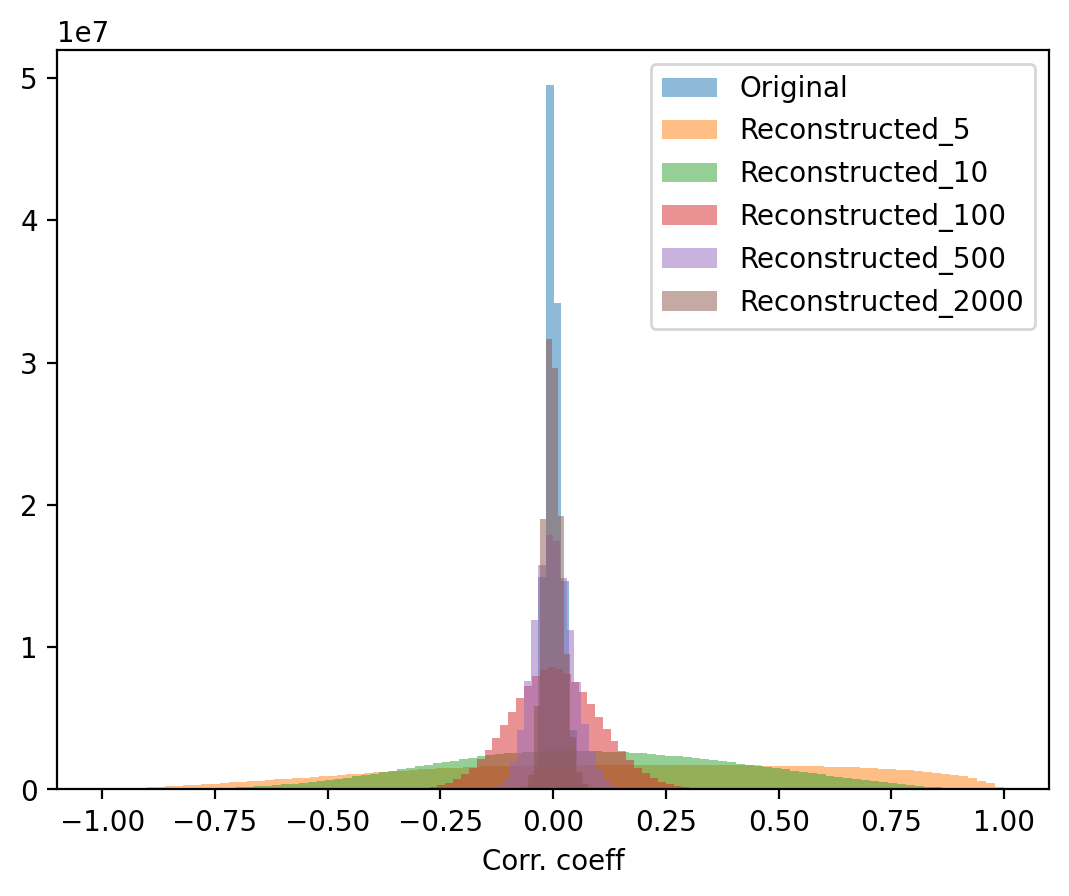

In [6]:
# - corr genes
adata_a_d = basic_qc(adata_a_d, min_genes_per_cell=10, min_cells_per_gene=10)

try: 
    X = adata_a_d.X.todense().A.copy()
except:
    X = adata_a_d.X.copy()

    
corr_un = calculate_corr(X)
aa = plt.hist(corr_un.flatten(), bins=100, label='Original', alpha=0.5)
mask_zeros = (X==0)

for n_components in [5, 10, 100, 500, 2000]:
    print(n_components)
    X_reconstructed = denoise(X, n_components)
    X_reconstructed = np.where(mask_zeros, X_reconstructed, 0)
    corr_un_den = calculate_corr(X_reconstructed)
    aa = plt.hist(corr_un_den.flatten(), bins=100, label=f'Reconstructed_{n_components}', alpha=0.5)
plt.legend()
plt.xlabel('Corr. coeff')

## Evaluate ranking

In [197]:
def analyse_corr(adata_ref, X_corrected):
    # - determine hvgs for ctr
    adata_ref = adata_a_d.copy()

    sc.pp.highly_variable_genes(adata_ref, n_top_genes=1000)
    mask_hvgs = adata_ref.var['highly_variable']
    hvgs = adata_ref.var_names[mask_hvgs]

    # - determine corr for ctr
    X = adata_ref.X.todense().A
    corr_mat = calculate_corr(X[:, mask_hvgs])
    corr_df = efficient_melting(corr_mat, hvgs)
    corr_df['link'] = corr_df['source'] + '_' + corr_df['target']

    # - determine top n links with their ranking
    n_top_links = 100
    corr_df['rank'] = corr_df.weight.abs().rank(ascending=False)  
    top_links_ref = corr_df.sort_values(by='rank', key=abs, ascending=True)[:n_top_links][['link','rank']].set_index('link')

    # - determine corr for corrected X
    corr_mat_corrected = calculate_corr(X_corrected[:, mask_hvgs])
    corr_df_corrected = efficient_melting(corr_mat_corrected, hvgs)
    corr_df_corrected['link'] = corr_df_corrected['source'] + '_' + corr_df_corrected['target']

    # - detrmine rank change 
    corr_df_corrected['rank'] = corr_df_corrected.weight.abs().rank(ascending=False) 
    top_links_corrected = corr_df_corrected[corr_df_corrected.link.isin(top_links_ref.index)][['link','rank']].set_index('link')

    top_links = pd.concat([top_links_ref, top_links_corrected], axis=1)
    top_links.columns = ['ref', 'corrected']

    # - determine p value for top 1000 links
    corr_df_sub = corr_df[corr_df['rank']<1000]
    corr_df_merged = corr_df_sub[['link','rank','weight']].merge(corr_df_corrected[['link','rank','weight']], on='link', how='left')

    u_stat, p_value = stats.mannwhitneyu(list(corr_df_merged['weight_x'].values), list(corr_df_merged['weight_y'].values))


    return corr_df, corr_df_corrected, top_links, p_value

In [111]:
# - create corr
adata_ref = adata_a_d.copy()

for i, n_components in enumerate([5, 10, 100, 2000]):
    X_corrected = denoise_func(X, n_components)

    corr_df, corr_df_corrected, top_links, p_value = analyse_corr(adata_ref, X_corrected)

    print(f'n_latent: {n_components} \t difference p_value: {p_value}')

    top_links.columns = [-1, n_components]
    if i == 0:
        top_links_all = top_links
    else:
        top_links_all = pd.concat([top_links_all, top_links[[n_components]]], axis=1)


n_latent: 5 	 difference p_value: 1.3075364875356457e-235
n_latent: 10 	 difference p_value: 5.819739491927061e-208
n_latent: 100 	 difference p_value: 9.81432299356045e-83


KeyboardInterrupt: 

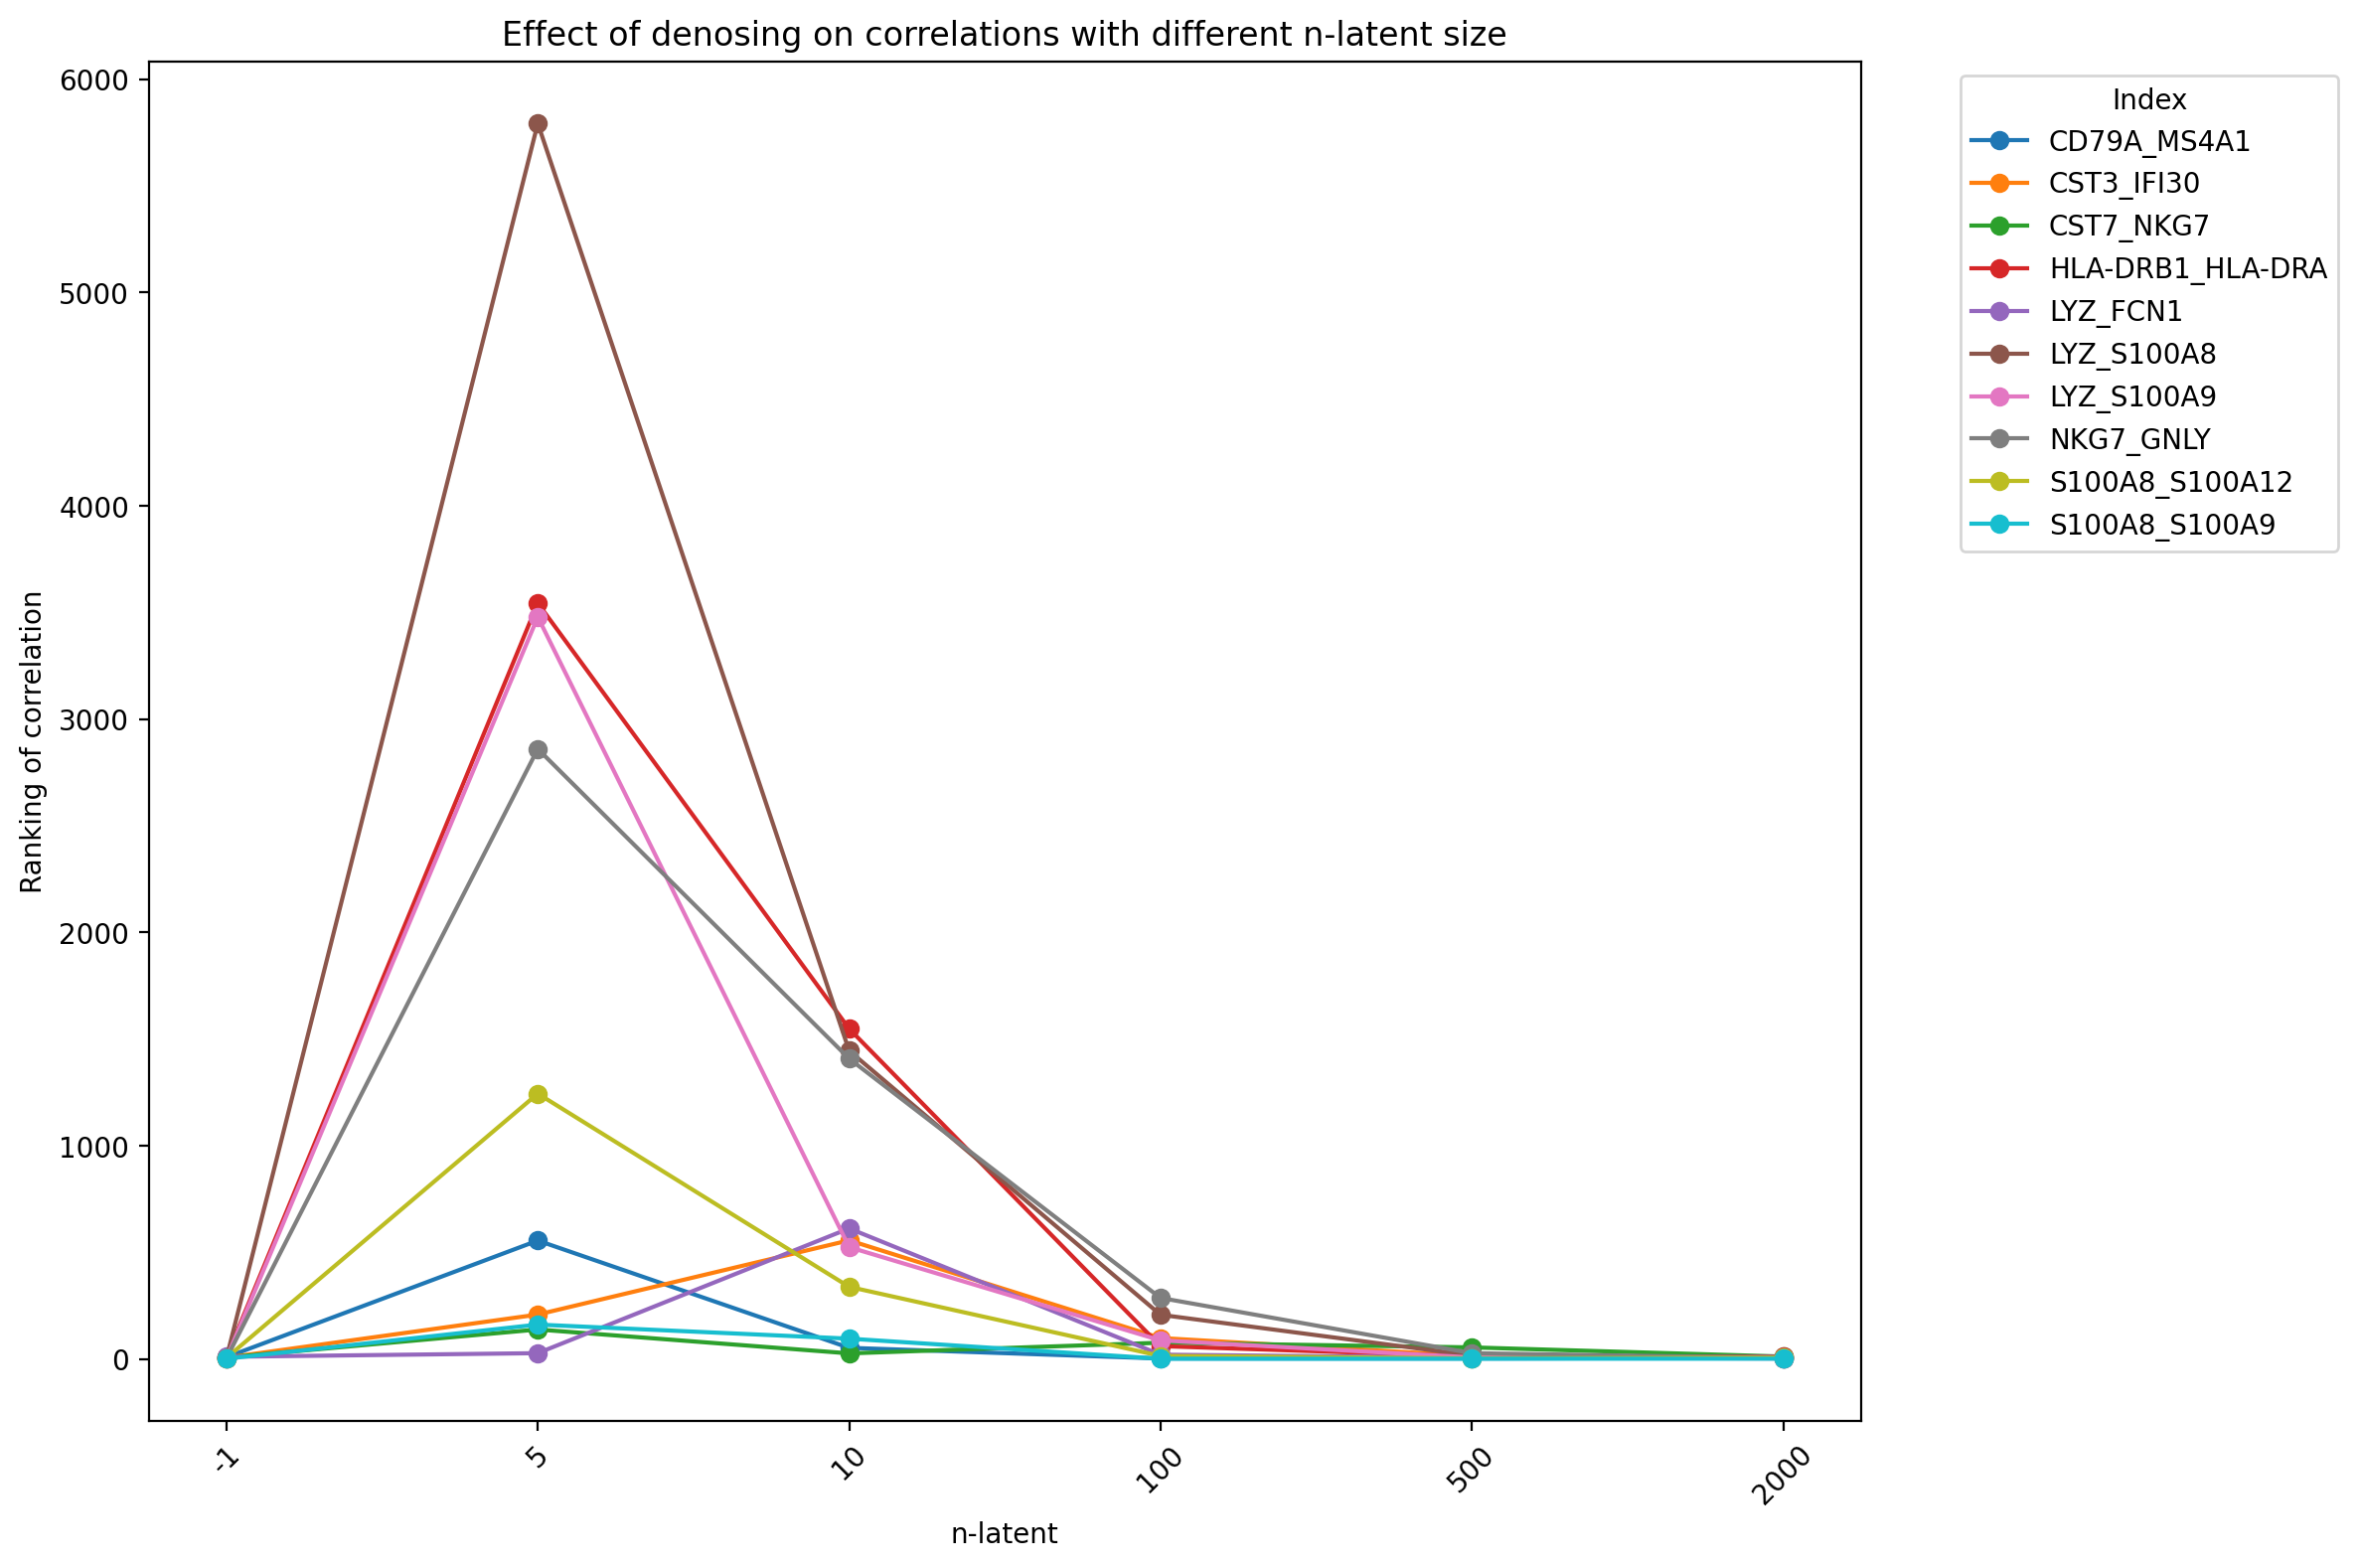

In [36]:
# Assuming `df` is your DataFrame
df = top_links_all

plt.figure(figsize=(12, 8))

# Generate x positions based on the number of columns
x_positions = np.arange(df.shape[1])

# Plot each row using `x_positions` as the x-axis
for index, row in df.iterrows():
    plt.plot(x_positions, row.values, marker='o', label=index)

# Set x-axis ticks to `x_positions` and label them with the actual column names
plt.xticks(ticks=x_positions, labels=df.columns, rotation=45)
plt.xlabel("n-latent")
plt.ylabel("Ranking of correlation")
plt.title("Effect of denosing on correlations with different n-latent size")

# Add legend outside the plot for clarity
plt.legend(title="Index", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()

# Data preprocessing

In [128]:
adata_all = ad.read_h5ad('input/adata_bootstrapped.h5ad')
adata_all_a = adata_all[adata_all.obs.age_group=='34-']
adata_all_donors = adata_all_a[adata_all_a.obs.donor_id.isin(adata_all_a.obs.donor_id.unique()[:5])]
adata_all_donors.write('output/data/adata_34_5donors.h5ad')

In [154]:
sc.pp.normalize_total(adata_all_donors)
sc.pp.log1p(adata_all_donors)

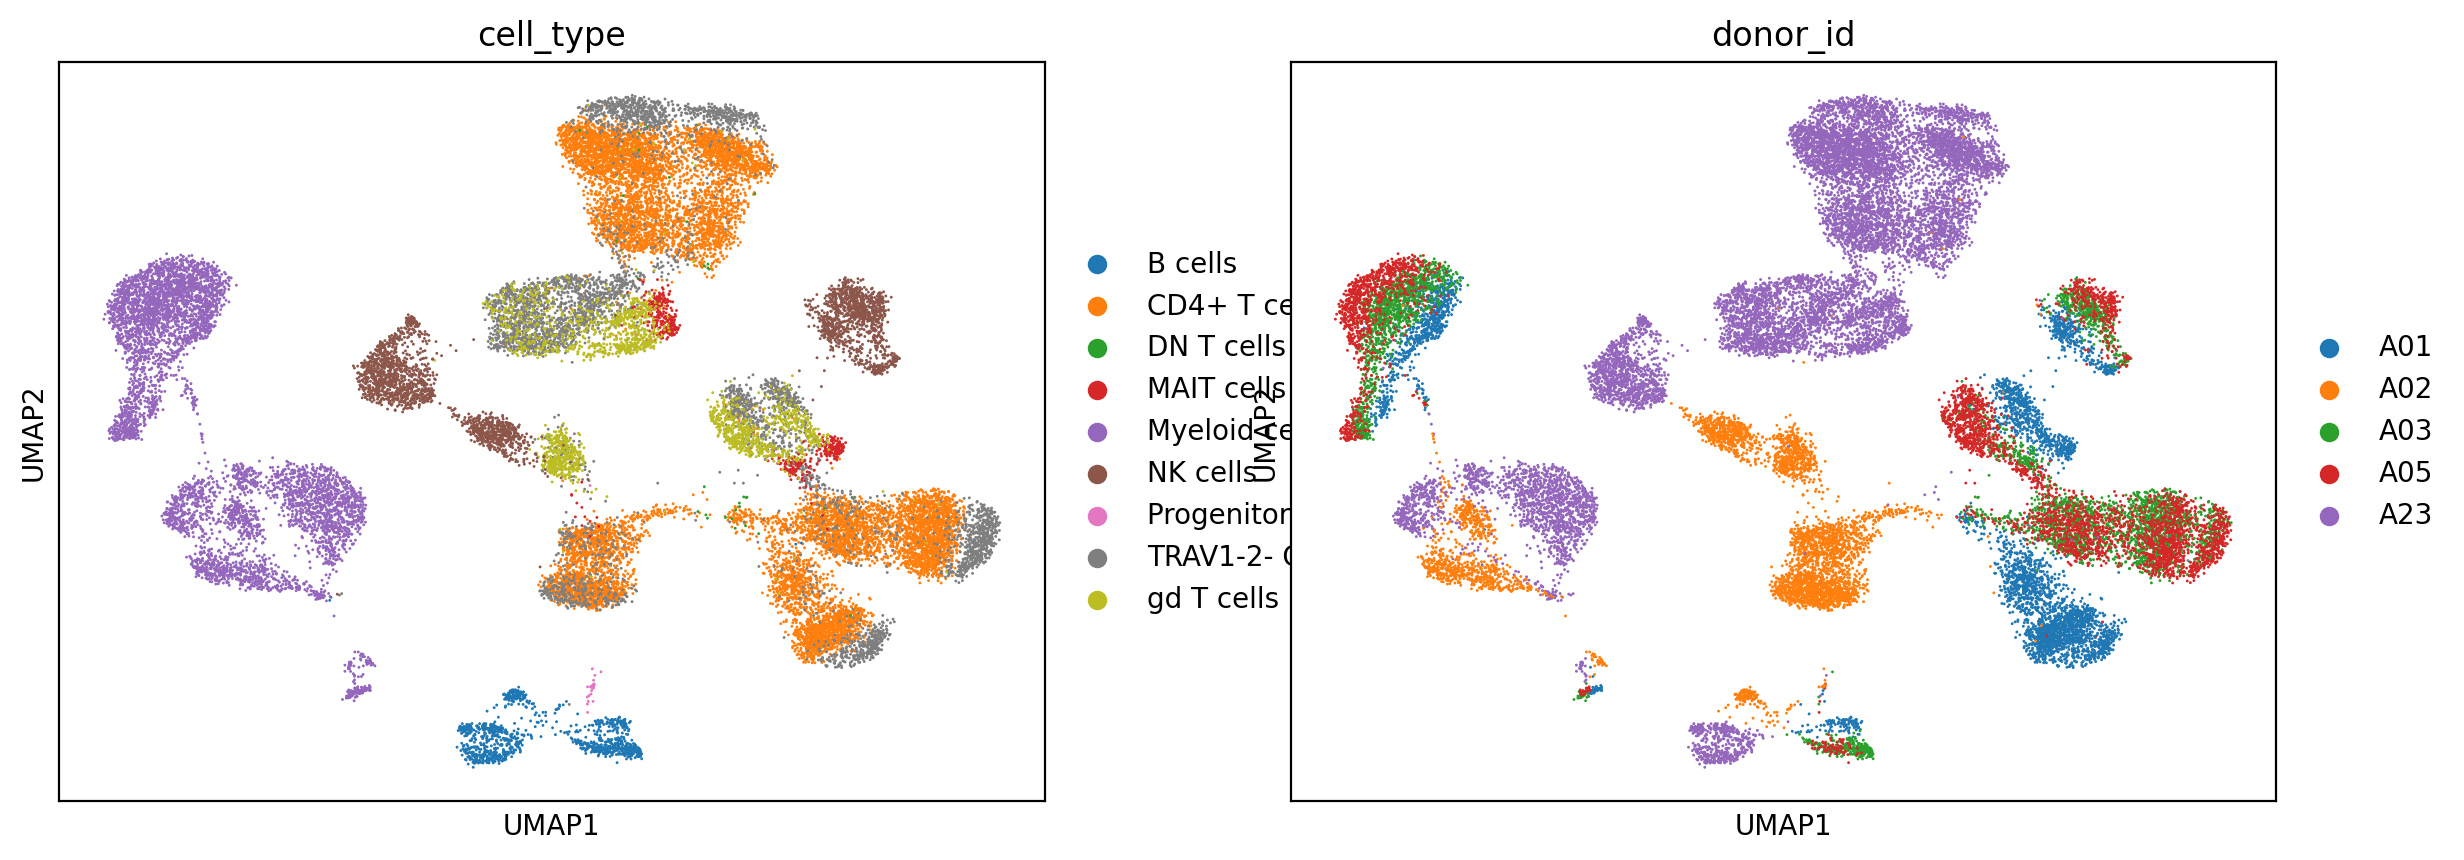

In [155]:
# - uncorrected
sc.pp.neighbors(adata_all_donors)
sc.tl.umap(adata_all_donors)
sc.pl.umap(adata_all_donors, color=['cell_type','donor_id'])

# Evaluate

In [191]:
adata_all_donors = ad.read_h5ad('output/data/adata_34_5donors.h5ad')
sc.pp.normalize_total(adata_all_donors)
sc.pp.log1p(adata_all_donors)
X_norm = adata_all_donors.X.todense().A

# scGEN

In [183]:
adata_bc_scgen = ad.read_h5ad('output/data/adata_34_5donors_bc_scgen.h5ad')


In [196]:
scgen_corrected = adata_bc_scgen.layers['scgen_corrected']

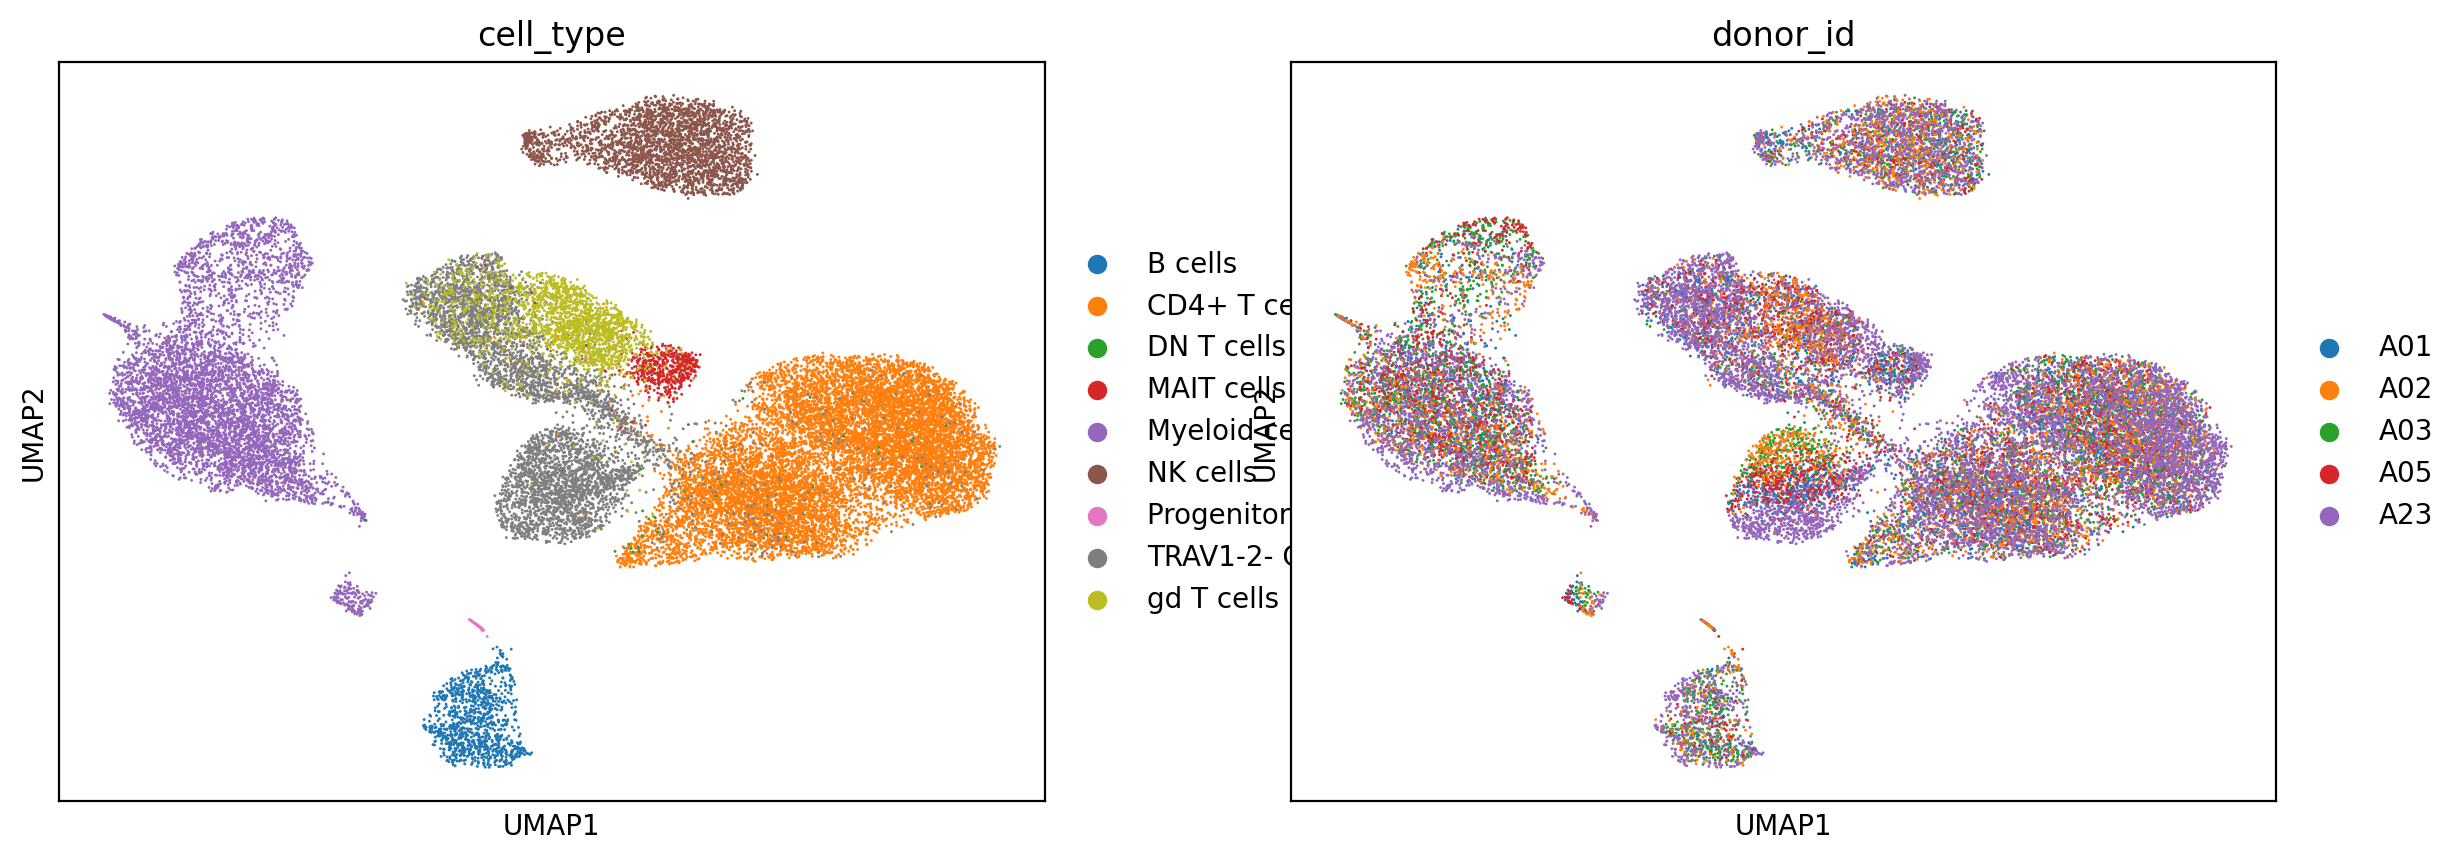

In [189]:
# - corrected
sc.pp.pca(adata_bc_scgen, layer='scgen_corrected')
sc.pp.neighbors(adata_bc_scgen)
sc.tl.umap(adata_bc_scgen)
sc.pl.umap(adata_bc_scgen, color=['cell_type','donor_id'])

mean_squared_error: 	 0.03368950274449652


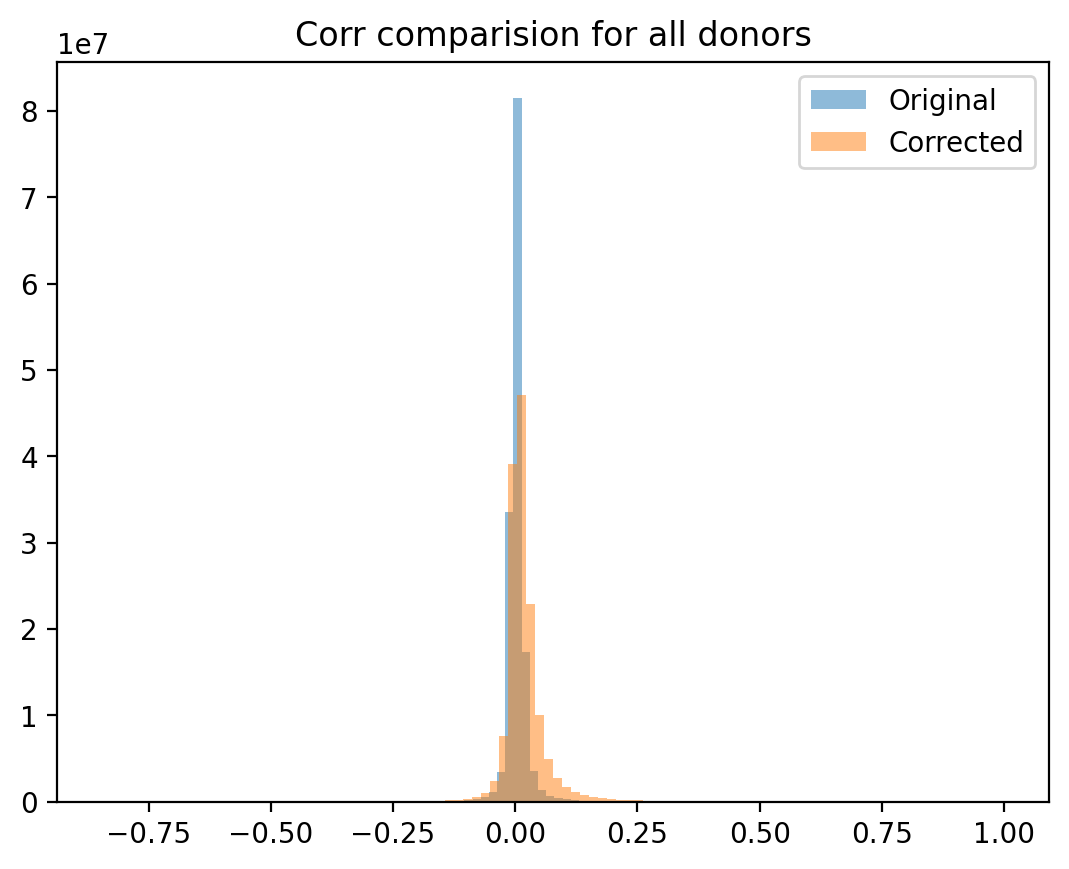

donor_id: A23 	 difference p_value: 7.494586061630597e-35 	 difference in ranking: 8750.0


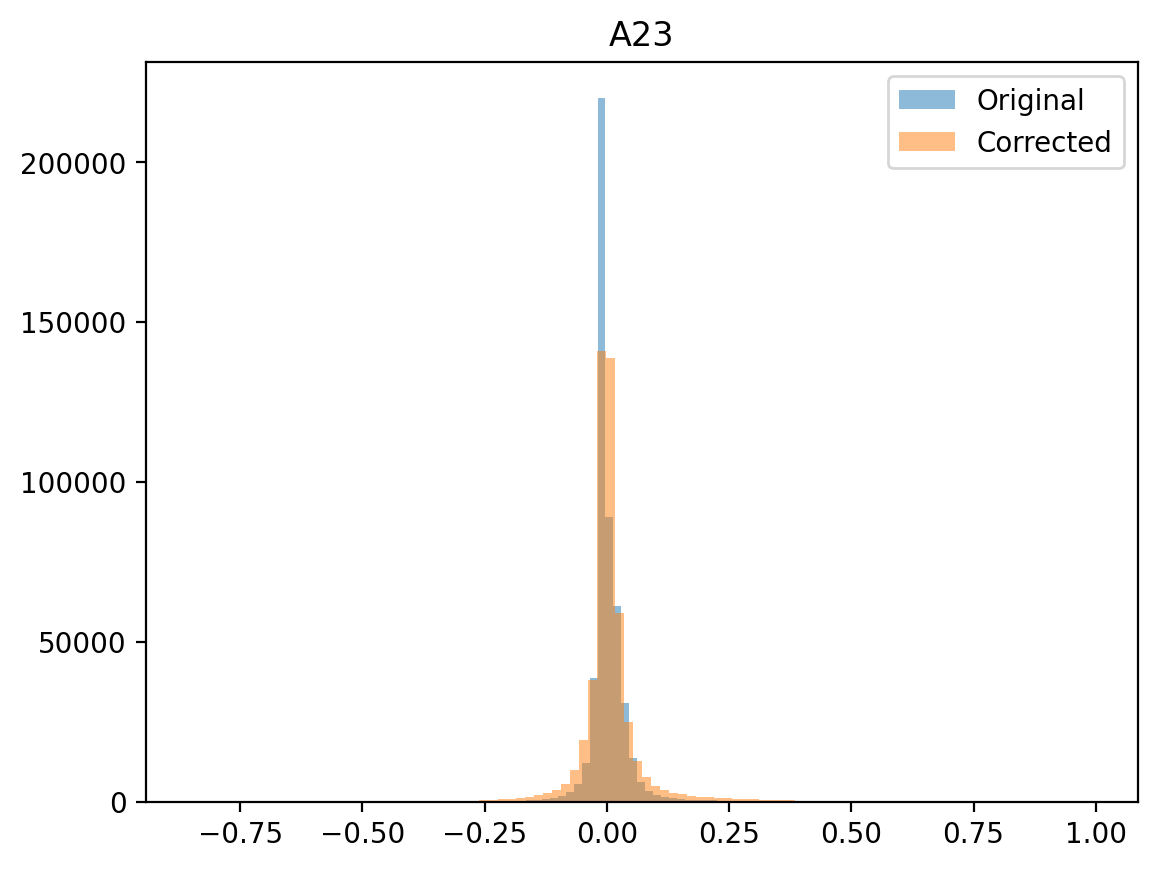

donor_id: A01 	 difference p_value: 2.2882360151978977e-06 	 difference in ranking: 187309.0


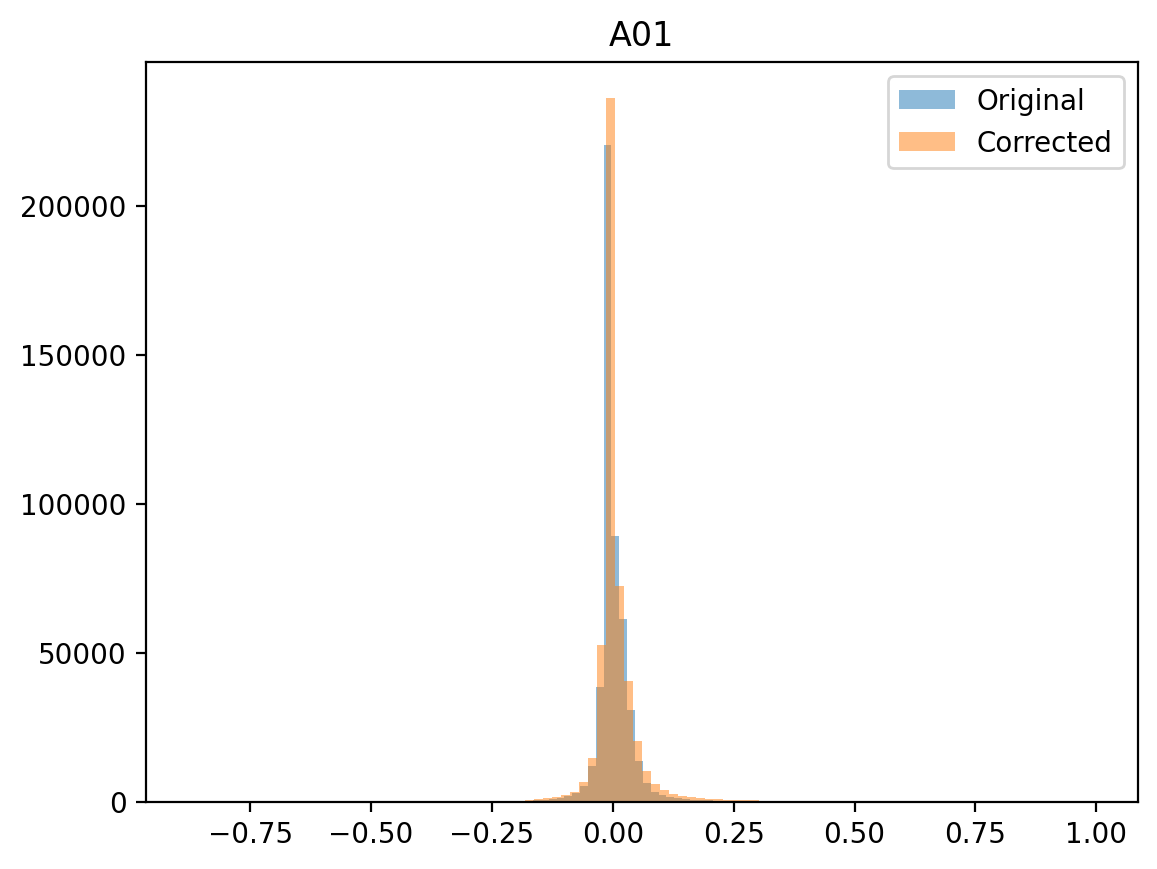

donor_id: A03 	 difference p_value: 3.213847912181138e-15 	 difference in ranking: 477970.0


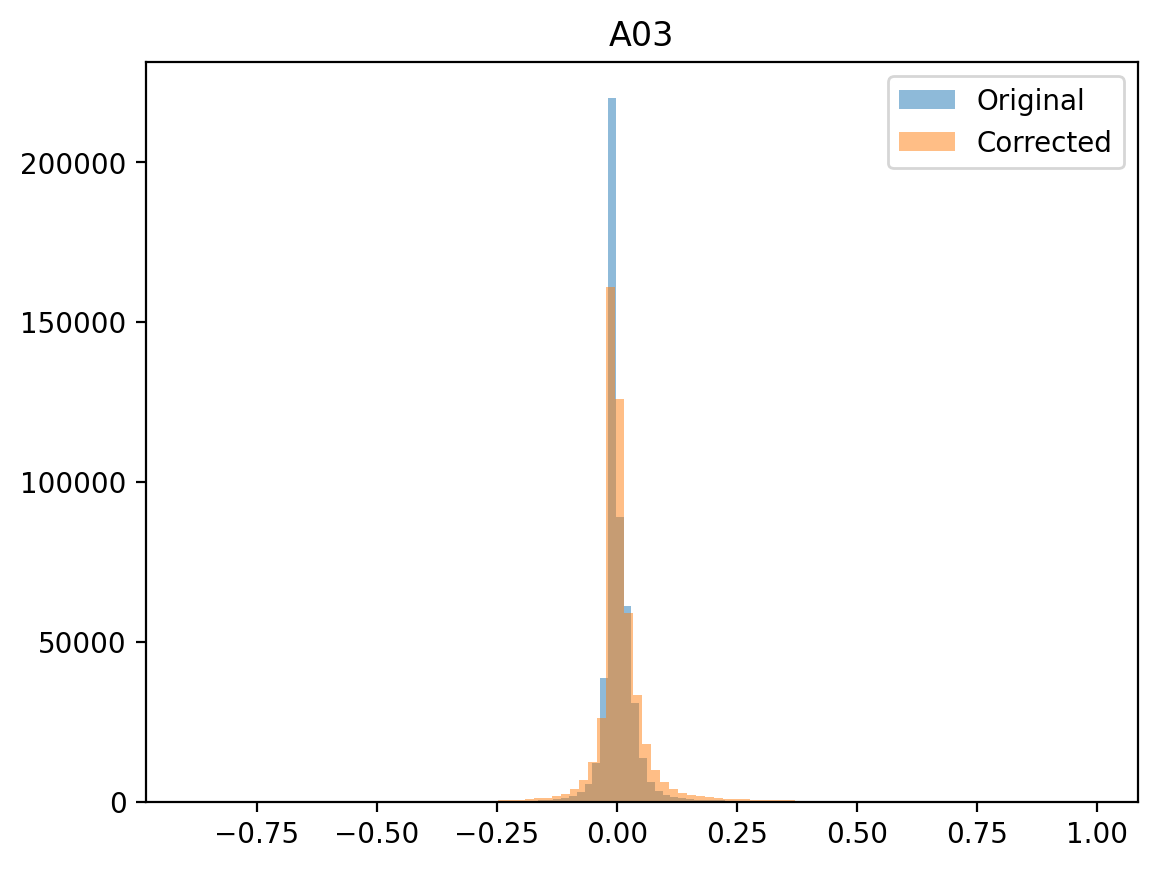

donor_id: A05 	 difference p_value: 2.2181009815089045e-14 	 difference in ranking: 731591.0


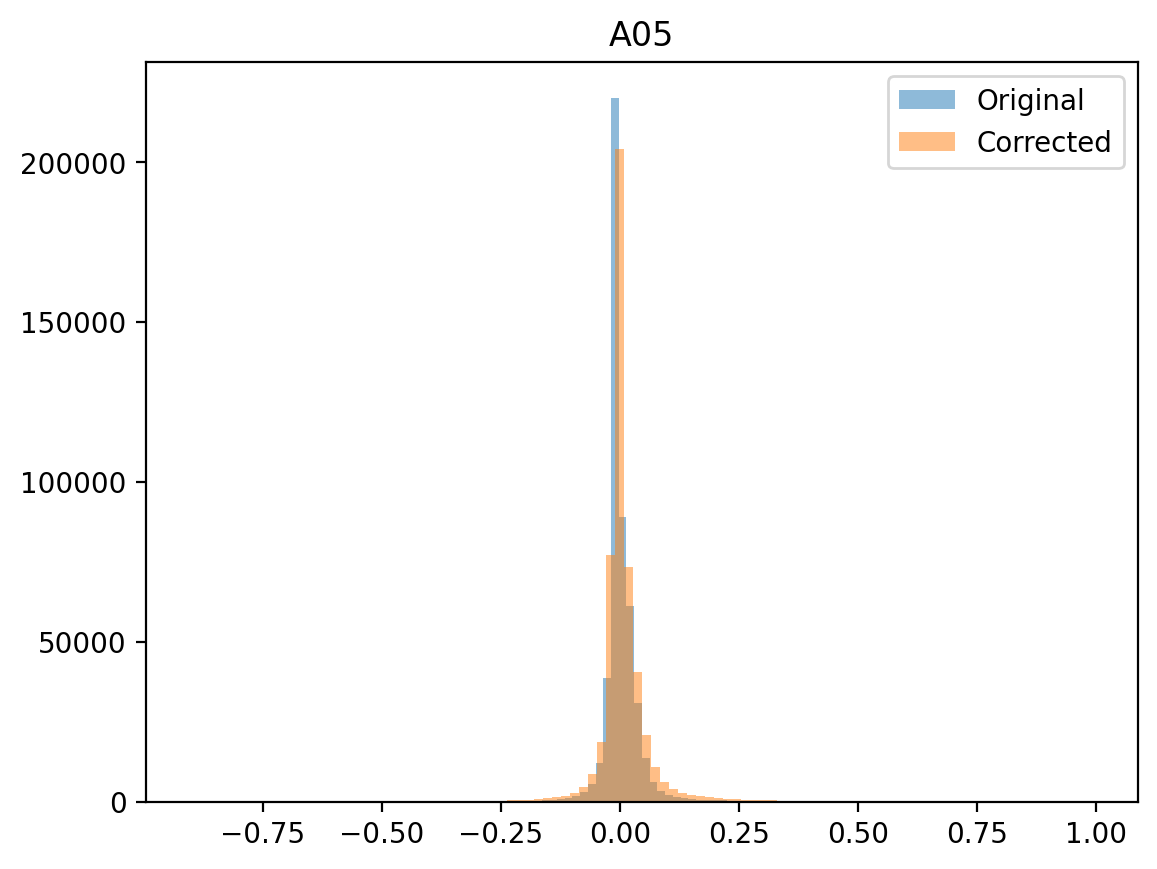

donor_id: A02 	 difference p_value: 1.3155794116724231e-17 	 difference in ranking: 4608.0


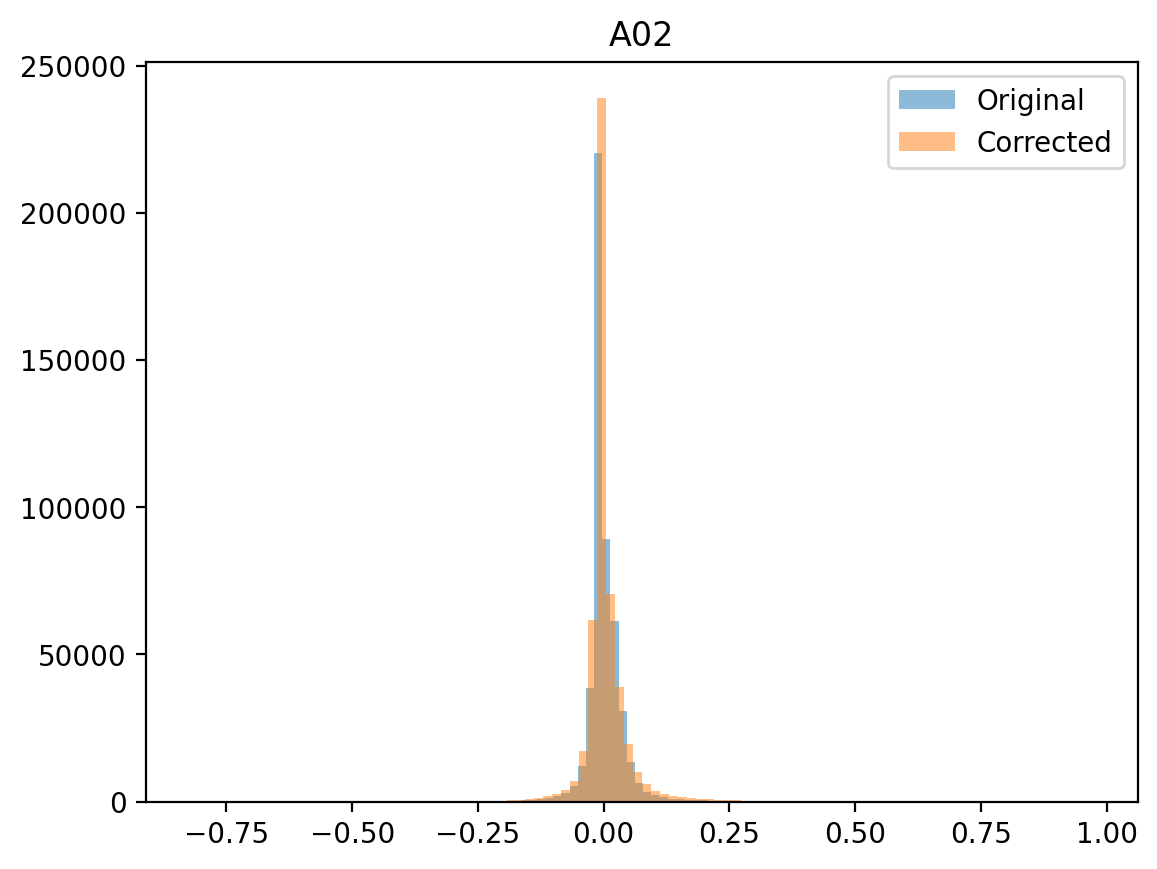

In [198]:
def metric_bc(X_norm, X_corrected, adata):
    mask_zeros = X_norm == 0
    X_corrected[mask_zeros] = 0
    # - mse 
    values_c = X_corrected.flatten()
    values_o = X_norm.flatten()
    print('mean_squared_error: \t', mean_squared_error(values_c, values_o))

    # - corr for all data (all donors) -> we expect to see batch effects in the uncorrected data
    corr_all = calculate_corr(X_norm)
    corr_corrected_all = calculate_corr(X_corrected)
    aa = plt.hist(corr_all.flatten(), bins=100, label='Original', alpha=0.5)
    aa = plt.hist(corr_corrected_all.flatten(), bins=100, label='Corrected', alpha=0.5)
    plt.legend()
    plt.title('Corr comparision for all donors')
    plt.show()

    # - per donor evaluation
    top_links_dict = {}
    for donor_id in adata.obs.donor_id.unique():
        mask = adata.obs.donor_id==donor_id

        adata_a_d = adata[mask, :]
        X_corrected_d = X_corrected[mask,:]

        corr_df, corr_df_corrected, top_links, p_value = analyse_corr(adata_a_d, X_corrected_d)

        print(f"donor_id: {donor_id} \t difference p_value: {p_value} \t difference in ranking: {np.abs(np.sum(top_links['ref']-top_links['corrected']))}")

        # - plot dist
        aa = plt.hist(corr_df.weight, bins=100, label='Original', alpha=0.5)
        aa = plt.hist(corr_df_corrected.weight, bins=100, label='Corrected', alpha=0.5)
        plt.legend()
        plt.title(donor_id)
        plt.show()
metric_bc(X_norm, scgen_corrected, adata_all_donors)

# Combat

In [156]:
# - correct 
X_corrected = sc.pp.combat(adata_all_donors, key='donor_id', inplace=False)  
# - mask the zero ones 
X_corrected_masked = X_corrected.copy()
X_corrected_masked[adata_all_donors.X.todense().A==0] = 0

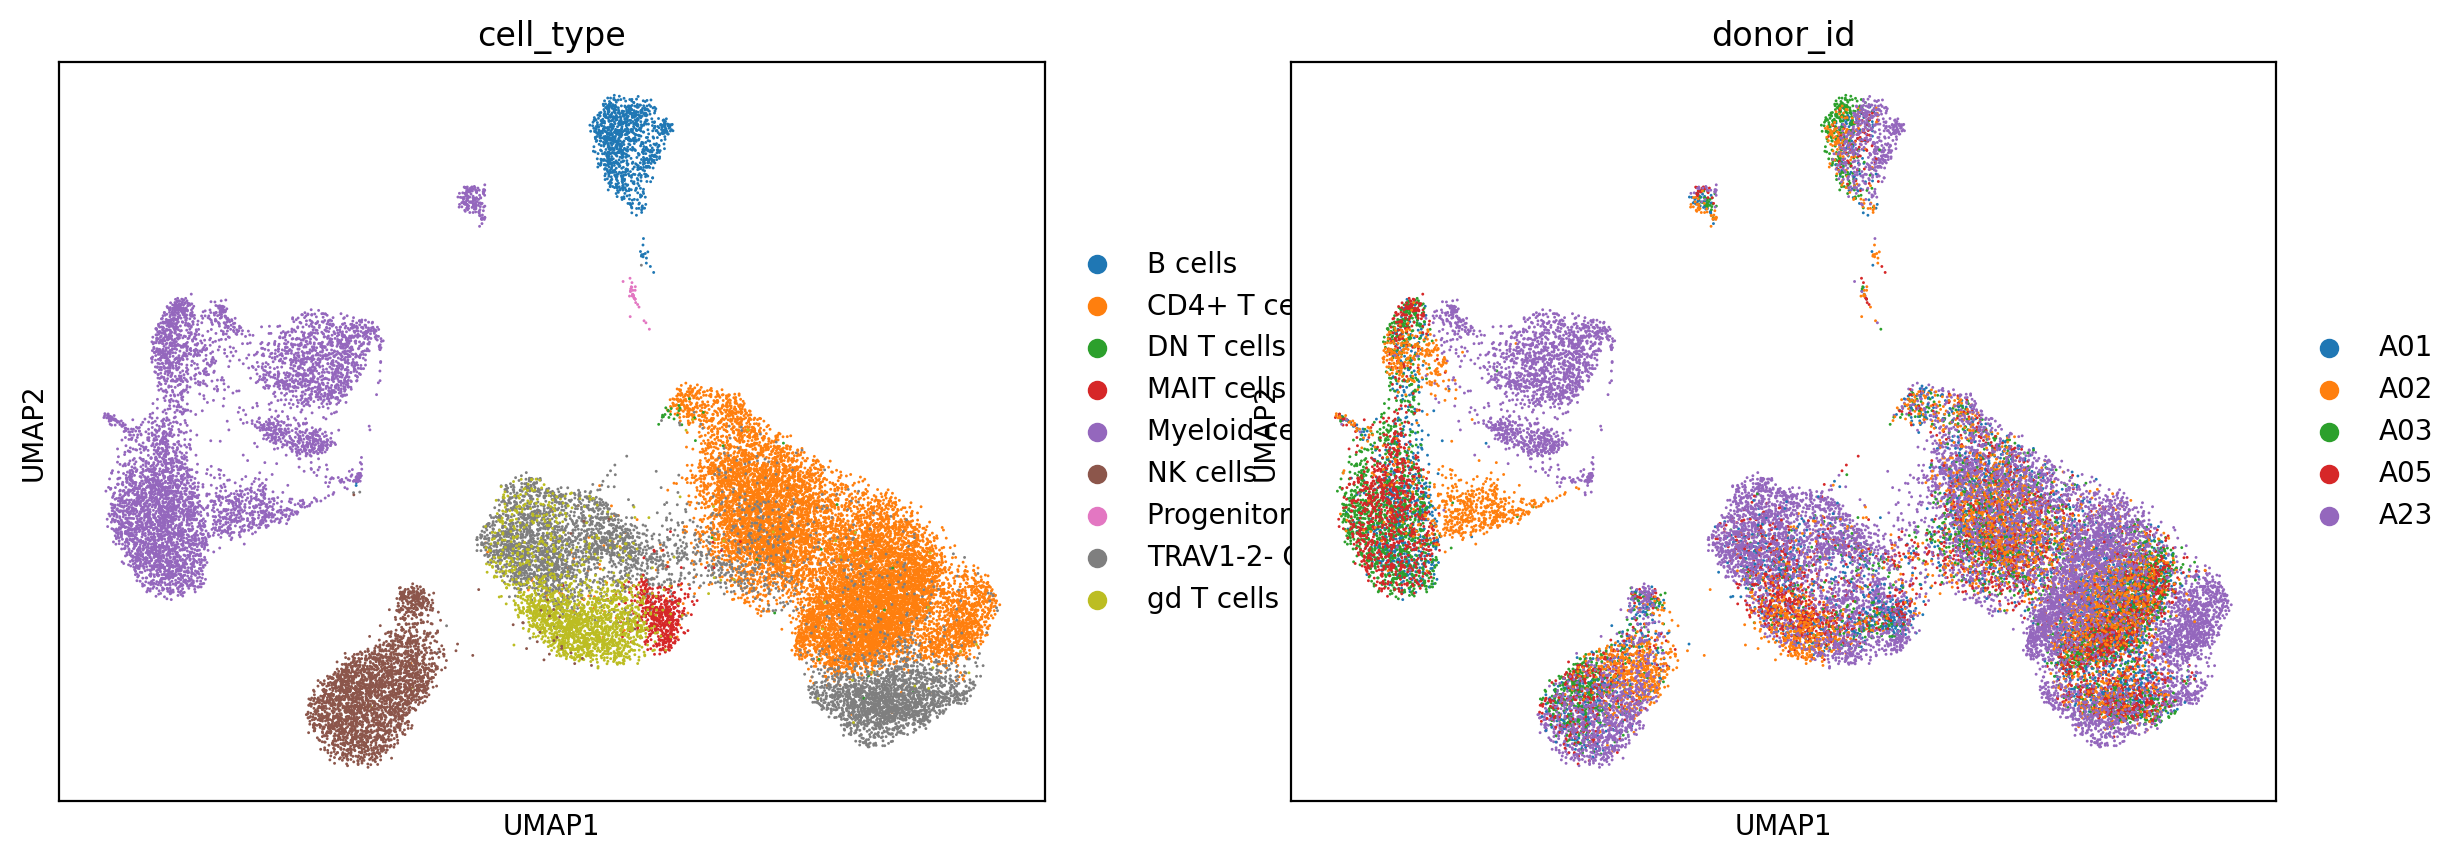

In [162]:
# - umap
adata_all_donors.layers['combat'] = X_corrected
sc.pp.pca(adata_all_donors, layer='combat')
sc.pp.neighbors(adata_all_donors)
sc.tl.umap(adata_all_donors)
sc.pl.umap(adata_all_donors, color=['cell_type','donor_id'])